In [4]:
print("AJAY KRISHNAN T - 24BAD006")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical

# PART A: DATASET PREPARATION

try:
    from datasets import load_dataset
    dataset = load_dataset("Trelis/tiny-shakespeare")  # parquet-based mirror
    text = dataset["train"]["Text"][0] if "Text" in dataset["train"].column_names \
        else dataset["train"]["text"][0]
except Exception as e:
    print("HF parquet load failed, falling back to raw text file:", e)
    # Option 2 (fallback): fetch the raw Tiny Shakespeare text directly
    import urllib.request
    url = ("https://raw.githubusercontent.com/karpathy/char-rnn/master/"
           "data/tinyshakespeare/input.txt")
    text = urllib.request.urlopen(url).read().decode("utf-8")

# Explore the dataset
print("Total characters in dataset:", len(text))
print("Sample text:\n", text[:300])

# Convert text to lowercase
text = text.lower()

# Use a manageable subset for faster training/demo purposes
text = text[:50000]

# Tokenize the text into individual words
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)


input_sequences = []
for line in text.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[: i + 1]
        input_sequences.append(n_gram_sequence)

# Apply sequence padding so all inputs are of equal length
max_sequence_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(
    input_sequences, maxlen=max_sequence_len, padding="pre"
)

# Split into predictors (X) and label (y) — last word in each sequence is the target
X = input_sequences[:, :-1]
labels = input_sequences[:, -1]
y = to_categorical(labels, num_classes=total_words)

# Split into training and validation sets
split_idx = int(0.9 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

AJAY KRISHNAN T - 24BAD006


README.md:   0%|          | 0.00/497 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/119k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/472 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

Total characters in dataset: 3131
Sample text:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us
Vocabulary size: 260
Training samples: 419
Validation samples: 47


In [5]:
print("AJAY KRISHNAN T - 24BAD006")

# PART B: IMPLEMENTING THE RNN MODEL


embedding_dim = 100
rnn_units = 150

model = Sequential([
    Embedding(input_dim=total_words, output_dim=embedding_dim,
              input_length=max_sequence_len - 1),
    SimpleRNN(rnn_units),
    Dense(total_words, activation="softmax"),
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

model.summary()

AJAY KRISHNAN T - 24BAD006


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

AJAY KRISHNAN T - 24BAD006
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.0286 - loss: 5.5443 - val_accuracy: 0.0000e+00 - val_loss: 5.6054
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0525 - loss: 5.3450 - val_accuracy: 0.0000e+00 - val_loss: 5.7922
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0453 - loss: 5.1510 - val_accuracy: 0.0000e+00 - val_loss: 5.9380
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0477 - loss: 5.0512 - val_accuracy: 0.0426 - val_loss: 6.0460
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0716 - loss: 4.9715 - val_accuracy: 0.0213 - val_loss: 6.0079
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0811 - loss: 4.8812 - val_accuracy: 0.0000e+00 - val_loss: 6.1464
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0955 - loss: 4.7989 - val_accuracy: 0.0213 - val_loss: 6.0729
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1050 - loss: 4.7151

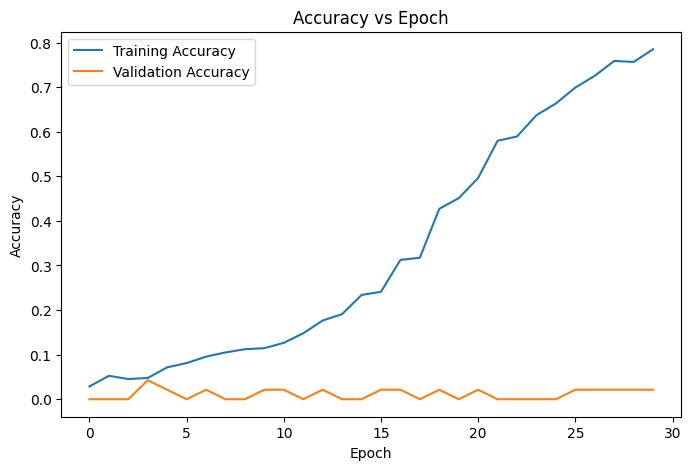

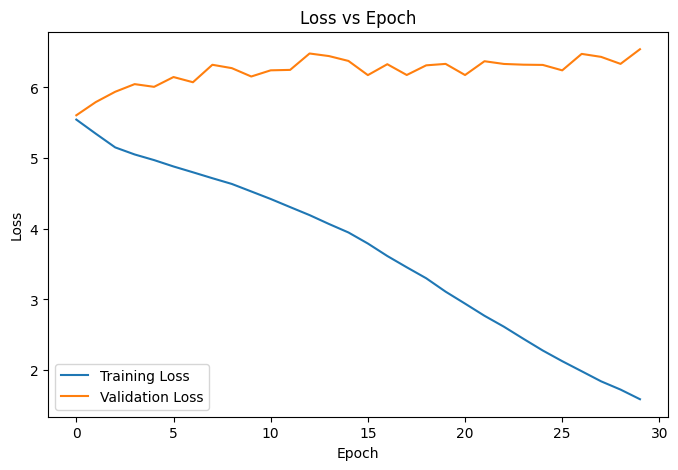

In [6]:
print("AJAY KRISHNAN T - 24BAD006")

# PART C: TRAINING AND PERFORMANCE EVALUATION


EPOCHS = 30
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

# Record final metrics
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])

# Visualize Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.savefig("accuracy_vs_epoch.png")
plt.show()

# Visualize Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.savefig("loss_vs_epoch.png")
plt.show()

In [7]:
print("AJAY KRISHNAN T - 24BAD006")


# PART D: TEXT GENERATION

print("=" * 50)
print("FINAL MODEL METRICS")
print("=" * 50)
print(f"Training accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Validation accuracy : {history.history['val_accuracy'][-1]:.4f}")
print(f"Training loss       : {history.history['loss'][-1]:.4f}")
print(f"Validation loss     : {history.history['val_loss'][-1]:.4f}")
print("=" * 50)

def generate_text(seed_text, next_words, model, max_sequence_len):
    """Generate text by repeatedly predicting the next word."""
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences(
            [token_list], maxlen=max_sequence_len - 1, padding="pre"
        )
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word
    return seed_text

# Generate multiple text samples using different seed inputs
seed_words = ["to be", "the king", "love is"]
for seed in seed_words:
    generated = generate_text(seed, next_words=20, model=model,
                               max_sequence_len=max_sequence_len)
    print(f"\nSeed: '{seed}'")
    print("Generated text:", generated)

AJAY KRISHNAN T - 24BAD006
FINAL MODEL METRICS
Training accuracy   : 0.7852
Validation accuracy : 0.0213
Training loss       : 1.5885
Validation loss     : 6.5399

Seed: 'to be'
Generated text: to be him good our his hath wants did it to revenge commonalty with soft conscienced men can be content to give

Seed: 'the king'
Generated text: the king patricians good you friends your wants care done he did covetous with being proud become good for him you neighbours

Seed: 'love is'
Generated text: love is you what we are to do the gods for i pray you these most charitable care done the accusations revenge
